# Political Compass — portable visual overview

        These two figures are generated from derived configuration coordinates,
        not from the withheld scorer. MCQ includes the full fourteen-language,
        three-precision design; chat uses the twelve primary checkpoint/protocol
        variants. Original scorer-dependent plotting is preserved in `legacy/`.
        Download `--component analysis` first, or use the tracked compact tables.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ANALYSIS_DIR = next((parent / 'tasks/political-compass/analysis'
                     for parent in [Path.cwd(), *Path.cwd().parents]
                     if (parent / 'tasks/political-compass/analysis/core.py').is_file()), None)
if ANALYSIS_DIR is None:
    raise FileNotFoundError('Run from within the release repository.')
sys.path.insert(0, str(ANALYSIS_DIR))
from core import (PRIMARY_MODELS, GEMMA_MODELS, QWEN_MODELS, load_mcq_configurations,
                  load_chat_configurations, plot_centroid_grid, analysis_table_path)
def source_label(path):
    try: return path.relative_to(ANALYSIS_DIR.parents[2])
    except ValueError: return path

In [2]:
selected = ANALYSIS_DIR.parent / 'selected-visuals'
selected.mkdir(parents=True, exist_ok=True)
mcq = load_mcq_configurations().rename(columns={
    'score_econ': 'economic', 'score_soc': 'social'})
chat = load_chat_configurations()
print('MCQ source:', source_label(analysis_table_path('pct_configuration_scores')))
print('Chat source:', source_label(analysis_table_path('chat_configuration_scores')))
assert len(mcq) == 43_200 and len(chat) == 21_600

MCQ source: /tmp/llm-bias-fresh-analysis/data/analysis_ready/political_compass/pct_configuration_scores.parquet
Chat source: /tmp/llm-bias-fresh-analysis/data/analysis_ready/political_compass/chat_configuration_scores.parquet


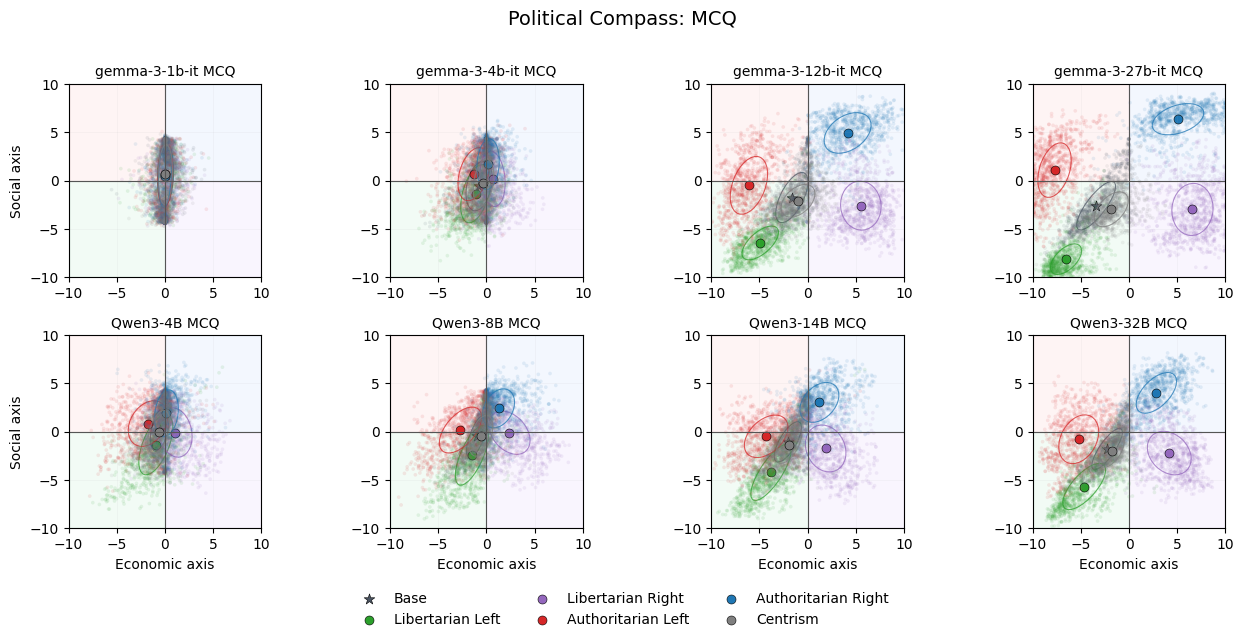

In [3]:
panels = [(f'{model}|mcq', f'{model} MCQ') for model in PRIMARY_MODELS]
figure = plot_centroid_grid(mcq, panels, title='Political Compass: MCQ')
figure.savefig(selected / 'political_compass_mcq_only.png', dpi=180,
               bbox_inches='tight')
plt.show()

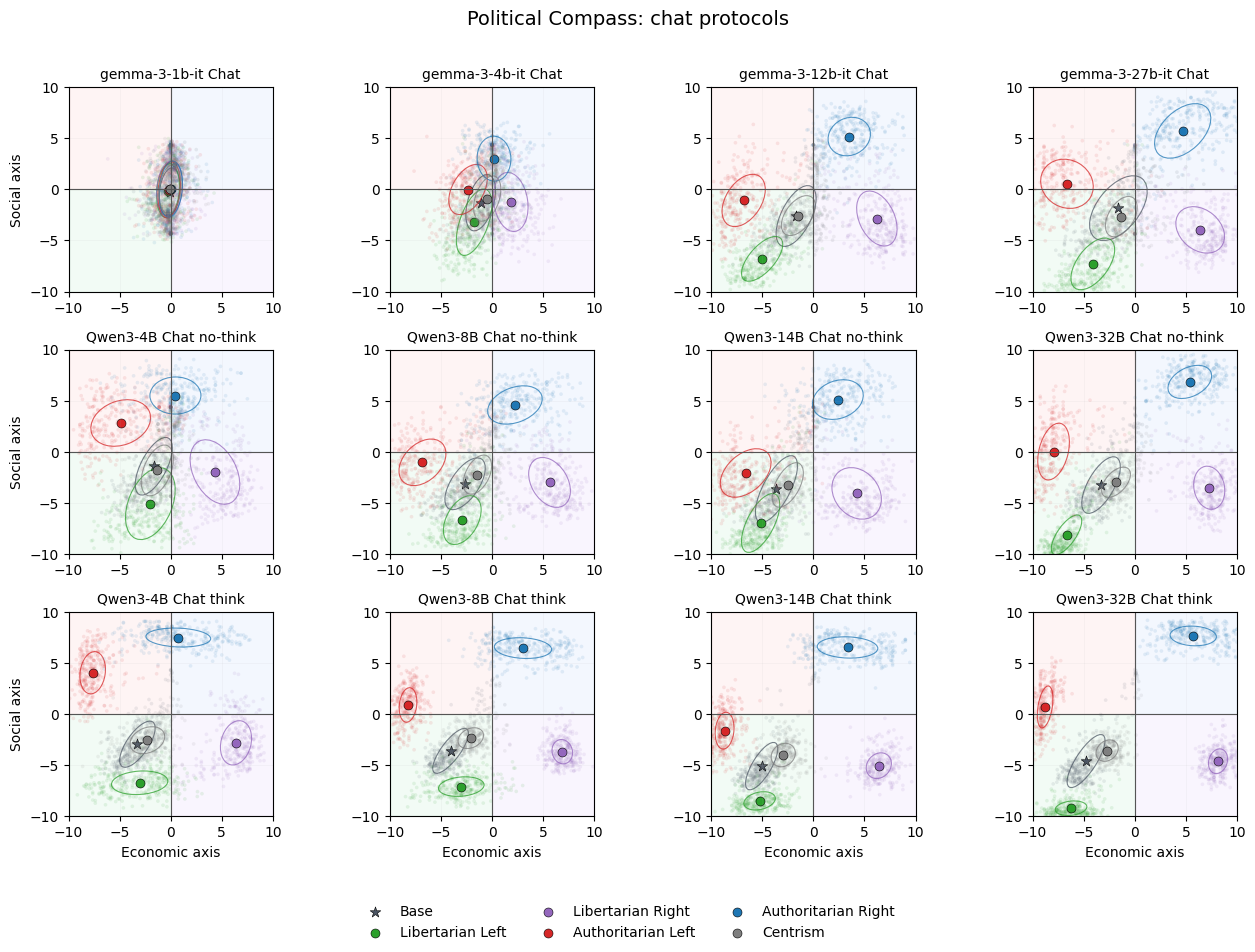

In [4]:
panels = [(f'{model}|standard', f'{model} Chat') for model in GEMMA_MODELS]
panels += [(f'{model}|no_think', f'{model} Chat no-think') for model in QWEN_MODELS]
panels += [(f'{model}|think', f'{model} Chat think') for model in QWEN_MODELS]
figure = plot_centroid_grid(chat, panels, title='Political Compass: chat protocols')
figure.savefig(selected / 'political_compass_chat_modes.png', dpi=180,
               bbox_inches='tight')
plt.show()

## Reading the plots

        Each faint point is the score of one complete 62-answer configuration.
        Colours identify the assigned persona. Outlined markers show that
        condition's mean position; ellipses show one standard deviation along
        the covariance axes, not uncertainty in the estimated mean. Position
        depends on the reconstructed instrument; it is not an intrinsic
        political identity or an answer-accuracy score.

        MCQ and chat sampled different configuration schedules. Only the Qwen
        think/no-think schedules are matched pairwise. Use the canonical
        comparison notebook for those paired diagnostics.